# Домашняя работа 1

In [4]:
!pip install torch torchvision torchaudio torch-geometric ogb --quiet


In [5]:
from ogb.nodeproppred import NodePropPredDataset
import networkx as nx
from networkx.algorithms.community import greedy_modularity_communities
from networkx.algorithms.community.quality import modularity

import matplotlib.pyplot as plt
from collections import defaultdict
import numpy as np
import igraph as ig


1. Загрузка данных

In [6]:
!rm -rf data/ogbn_arxiv


In [7]:
dataset = NodePropPredDataset(name='ogbn-arxiv', root='data')
graph, labels = dataset[0]

print("Количество узлов:", graph["num_nodes"])
print("Количество рёбер:", graph["edge_index"].shape[1])


Extracting data/arxiv.zip
Loading necessary files...
This might take a while.
Processing graphs...
Saving...
Количество узлов: 169343
Количество рёбер: 1166243


100%|██████████| 1/1 [00:00<00:00, 18978.75it/s]


In [25]:
edge_index = graph["edge_index"].T  # np.array (1.1M × 2)
G = nx.DiGraph()
G.add_edges_from(edge_index)
G = G.to_undirected()

Визуализируйте граф на семпле из 1000 узлов

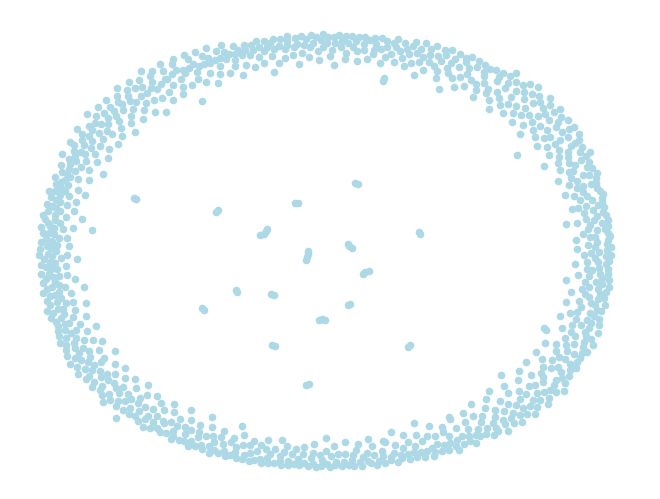

In [9]:
# TODO: визуализация

import random
nodes = random.sample(list(G.nodes()), 1000)

nx.draw(G.subgraph(nodes), with_labels=False, node_color="lightblue", node_size=20, width=0.2)
plt.show()

### Предварительный анализ

Произведем предварительный анализ графа

In [10]:
# TODO: средняя степень -- почему-то эта ячейка падала из-за обьем графа( )
sample_nodes = set(random.sample(list(G.nodes()), 10000))
H = G.subgraph(sample_nodes).copy()
avg_degree = sum(dict(H.degree()).values()) / H.number_of_nodes()
print(f"Средняя степень: {avg_degree:.2f}")

Средняя степень: 0.94


In [13]:
#nx не вывозит такой огромный граф, поэтому я буду использовать билиотеку igraph - она на плюсах, поэтому работает быстрее
edges = [(u, v, 1) for u, v in G.edges()]
g = ig.Graph(edges=edge_index.tolist(), directed=False)

In [14]:
# TODO: плотность графа
density = g.density()
print(f"Плотность: {density:.6f}")

Плотность: 0.000081


In [16]:
comps = g.components()
print("Компонент:", len(comps))
print("Размер крупнейшей:", max(len(c) for c in comps))


Компонент: 1
Размер крупнейшей: 169343


In [19]:
# TODO: диаметер графа
diameter =  g.diameter() # TODO
print(f"Диаметер графа: {diameter:.4f}")


Диаметер графа: 25.0000


In [20]:
# TODO: радиус графа
radius = g.radius()
print(f"Радиус графа: {radius:.4f}")

Радиус графа: 13.0000


### Анализ на центральность

Найдите узел с максимальной центральностью

In [24]:
# Вычисление центральности по степени (degree centrality)
#выводим только топ, тк иначе будем выводить вообще все для всех вершин:)
degree_centrality = nx.degree_centrality(G)
degree_centrality_top = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
print("Центральность по степени:", degree_centrality_top)

# Вычисление центральности по близости (closeness centrality)
closeness_centrality = nx.closeness_centrality(G)
closeness_centrality_top = sorted(closeness_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
print("Центральность по близости:", closeness_centrality_top)

# Вычисление центральности по междуузловой значимости (betweenness centrality)
betweenness_centrality = nx.betweenness_centrality(G)
betweenness_centrality_top =sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
print("Центральность по междуузловой значимости:", betweenness_centrality_top)


Центральность по степени: [(np.int64(1353), 0.07771846322825997), (np.int64(67166), 0.07408675933908894), (np.int64(25208), 0.054664525043993814), (np.int64(69794), 0.028250522611047466), (np.int64(93649), 0.025126666745402794), (np.int64(115359), 0.02387476231531457), (np.int64(22035), 0.022853161058685973), (np.int64(133376), 0.02277639333419943), (np.int64(106699), 0.02209138902339644), (np.int64(166425), 0.020237153216567657)]


### Анализ кластеров

In [26]:
# TODO: Вычислите средний кластерный коэффициент графа
global_cluster_coeff = nx.average_clustering(G)
print("Cредний кластерный коэффициент графа:", global_cluster_coeff)


Cредний кластерный коэффициент графа: 0.22612914062470996


In [27]:
# TODO: Вычислите коэффициент транзитивности
transitivity_coeff = nx.transitivity(G)
print("Коэффициент транзитивности графа:", transitivity_coeff)


Коэффициент транзитивности графа: 0.01620149151351999


### Поиск сообществ

Реализуйте 2 метода поиска сообществ:

1. С помощью готовой реализации в библиотеке NetworkX
2. Реализуйте самостоятельно класс с алгоритмом Clauset–Newman–Moore

Сравните полученные результаты

Алгоритм Clauset–Newman–Moore (CNM)

---

**1. Начальное состояние**

- Каждая вершина — отдельное сообщество.
- Вычисляем степени вершин и матрицу смежности.

---

**2. Вычисляем для всех пар сообществ** $(r, s)$, между которыми есть хотя бы одно ребро:

$$ \\Delta Q\_{rs} = 2 , (e\_{rs} - a_r a_s) $$

где:

- $e\_{rs}$ — доля рёбер между сообществами *r* и *s*, делённая на $2m$;
- $a_r = \\sum_t e\_{rt}$ — доля концов рёбер, инцидентных *r*.

---

**2.1. Доля концов рёбер, инцидентных вершинам из $r$**

Это часть всех концов рёбер в графе, которые принадлежат вершинам, входящим в сообщество $r$.

Эта величина обозначается как $a_r$ и вычисляется по формуле:

$$ a_r = \\frac{1}{2m} \\sum\_{i \\in r} k_i $$

где:

- $k_i$ — степень вершины $i$ (сколько у неё рёбер);
- $m$ — общее число рёбер в графе;
- $2m$ — общее количество **концов рёбер** (так как каждое ребро имеет два конца).

---

**3. Выбираем пару $(r, s)$** с максимальным $\\Delta Q$ и объединяем их.

---

**4. Обновляем:**

- значения $e\_{rt}, a_r$;
- новую модульность:\
  $$ Q \\leftarrow Q + \\Delta Q $$

---

**5. Повторяем**, пока $\\Delta Q &gt; 0$.

---

**6. Выбираем состояние с максимальным $Q$** как оптимальное разбиение.

Описание алгоритма - https://arxiv.org/pdf/cond-mat/0408187

In [30]:
class CNM:
    """
    Алгоритм Clauset–Newman–Moore для обнаружения сообществ.
    TODO: Заполните пропущенные участки кода.
    """

    def __init__(self, edges):
        self.graph = defaultdict(dict)
        for u, v, w in edges:
            if u == v: continue
            self.graph[u][v] = self.graph[u].get(v, 0) + w
            self.graph[v][u] = self.graph[v].get(u, 0) + w
        self.nodes = list(self.graph.keys())
        self.m = sum(sum(self.graph[u].values()) for u in self.nodes) / 2
        self.deg = {u: sum(self.graph[u].values()) for u in self.nodes}

    def fit(self, verbose=False):
        communities = {u: {u} for u in self.nodes}
        comm_id = {u: u for u in self.nodes}
        m2 = 2 * self.m
        a = {u: self.deg[u] / m2 for u in self.nodes}

        # TODO 0: Доля рёбер между сообществами
        e = defaultdict(dict)
        for u in self.nodes:
            cu = comm_id[u]
            for v, w in self.graph[u].items():
                cv = comm_id[v]
                e[cu][cv] = e[cu].get(cv, 0) + w / m2


        # Начальная модульность
        Q = -sum(a[c] ** 2 for c in a)

        # Основной цикл
        while True:
            best_dQ = 0
            best_pair = None

            # TODO 1: Найти пару (r, s) с максимальным ΔQ
            for r in list(e.keys()):
                for s in list(e[r].keys()):
                    if r >= s:
                        continue
                    dQ = 2 * (e[r].get(s, 0) - a[r] * a[s])
                    if dQ > best_dQ:
                        best_dQ = dQ
                        best_pair = (r, s)

            # TODO 2: Условие выхода
            if best_pair is None or best_dQ <= 0:
                break

            r, s = best_pair
            if verbose:
                print(f"Объединяем {r}, {s} с ΔQ={best_dQ:.6f}")

            # TODO 3: Объединение сообществ
            for node in communities[s]:
                comm_id[node] = r
                communities[r].add(node)
            communities[s].clear()


            # TODO 4: Обновление a, e, Q
            #  e
            for t in list(e[s].keys()):
                e[r][t] = e[r].get(t, 0) + e[s][t]
            del e[s]

            for k in list(e.keys()):
                if s in e[k]:
                    e[k][r] = e[k].get(r, 0) + e[k][s]
                    del e[k][s]

            #  a
            a[r] = a[r] + a[s]
            del a[s]

            # Q
            Q += best_dQ

        final_comms = [c for c in communities.values() if c]
        return final_comms, Q


In [32]:
import random

sample_nodes = set(random.sample(list(G.nodes()), 10000)) # даже на 30к очень больно для вычислительных ресурсов( 
H = G.subgraph(sample_nodes).copy()

edges = [(u, v, 1) for u, v in H.edges()] #добавляем веса
model = CNM(edges)
comms, Q_my = model.fit(verbose=True)

# NetworkX эталон
nx_comms = list(greedy_modularity_communities(G))
Q_nx = modularity(G, nx_comms)

print("\n=== Сравнение ===")
print("CNM (наш)  Q =", round(Q_my, 5))
print("NetworkX    Q =", round(Q_nx, 5))
print("Количество сообществ:", len(comms))


Объединяем 43003, 163842 с ΔQ=0.000248
Объединяем 65610, 118138 с ΔQ=0.000248
Объединяем 73190, 131164 с ΔQ=0.000248
Объединяем 65631, 126416 с ΔQ=0.000248
Объединяем 98405, 159813 с ΔQ=0.000248
Объединяем 65668, 88405 с ΔQ=0.000248
Объединяем 32962, 47561 с ΔQ=0.000248
Объединяем 62909, 164050 с ΔQ=0.000248
Объединяем 98537, 145367 с ΔQ=0.000248
Объединяем 65780, 114531 с ΔQ=0.000248
Объединяем 43145, 65824 с ΔQ=0.000248
Объединяем 33095, 70470 с ΔQ=0.000248
Объединяем 65863, 102640 с ΔQ=0.000248
Объединяем 131416, 139191 с ΔQ=0.000248
Объединяем 65937, 116613 с ΔQ=0.000248
Объединяем 419, 82213 с ΔQ=0.000248
Объединяем 33200, 94231 с ΔQ=0.000248
Объединяем 33204, 159851 с ΔQ=0.000248
Объединяем 441, 77034 с ΔQ=0.000248
Объединяем 33246, 34908 с ΔQ=0.000248
Объединяем 4738, 98804 с ΔQ=0.000248
Объединяем 79776, 164394 с ΔQ=0.000248
Объединяем 27315, 164406 с ΔQ=0.000248
Объединяем 88836, 98907 с ΔQ=0.000248
Объединяем 689, 23156 с ΔQ=0.000248
Объединяем 33487, 144468 с ΔQ=0.000248
Объ

KeyboardInterrupt: 

In [35]:

# NetworkX эталон
nx_comms = list(greedy_modularity_communities(H))
Q_nx = modularity(H, nx_comms)

print("\n=== Сравнение ===")
print("CNM (наш)  Q =", round(Q_my, 5))
print("NetworkX    Q =", round(Q_nx, 5))
print("Количество сообществ:", len(comms))


=== Сравнение ===
CNM (наш)  Q = 0.87511
NetworkX    Q = 0.87507
Количество сообществ: 659


Визуализация результатов

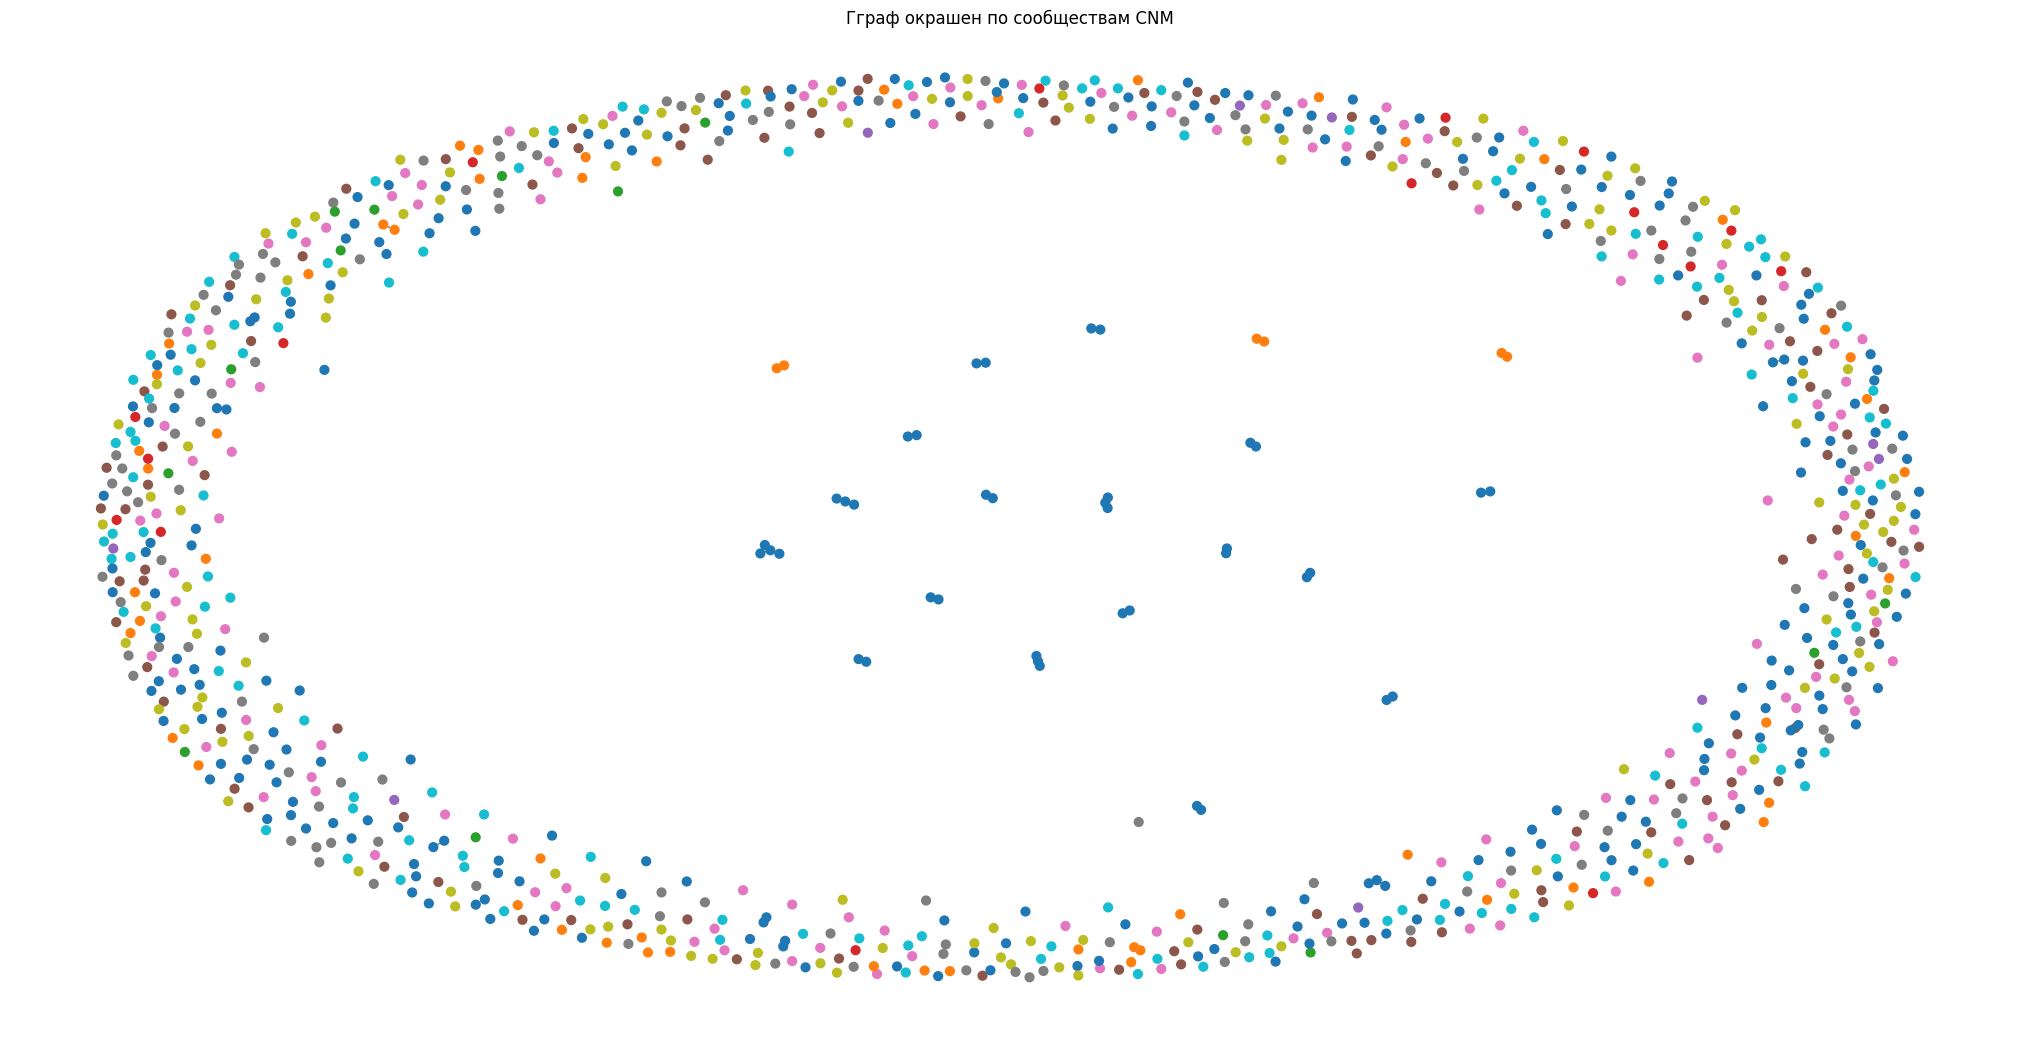

In [36]:
plt.figure(figsize=(20, 10))
sub_nodes = list(H.nodes)[:1000]
K = H.subgraph(sub_nodes)

# создаём отображение: node -> community_id
node2comm = {}
for i, comm in enumerate(nx_comms):
    for n in comm:
        node2comm[n] = i

colors = [node2comm.get(n, 0) for n in K.nodes()]
nx.draw(K, node_color=colors, node_size=40, edge_color="gray", with_labels=False, cmap="tab10")
plt.title("Гграф окрашен по сообществам CNM")
plt.show()